Used for nominal data( data is categorical with no specific relationship)

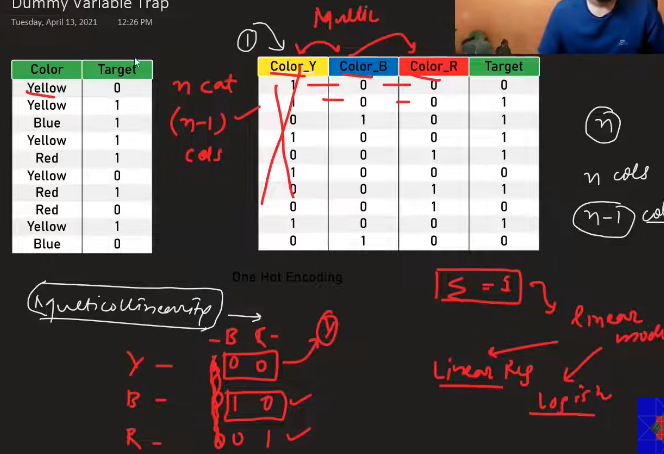

To preserve multicolinearity, one of the n dummy cols is removed(here yellow)--(n-1) remain.

In [118]:
import numpy as np
import pandas as pd

In [119]:
df=pd.read_csv('cars.csv')
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
4924,Mahindra,140000,Diesel,Second Owner,400000
1316,Maruti,150000,Petrol,Third Owner,150000
3098,Ford,45000,Diesel,First Owner,725000
7171,Tata,90000,Diesel,First Owner,150000
1942,Maruti,110000,Petrol,Second Owner,200000


In [120]:
df['brand'].value_counts()
# As we can see some n(brand) are very less, we can take them as 'others'.

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Force               6
Land                6
Isuzu               5
Kia                 4
Ambassador          4
Daewoo              3
MG                  3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [121]:
df['fuel'].value_counts()
# CNG,LPG can be taken as others.

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [122]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

# OHE using Pandas

In [123]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=np.int32)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


# K-1 OHE
to remove first column

In [36]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True,dtype=np.int32)
# fuel ka 1st column hatgya(fuel_cng)
# owner ka 1st column hotgya(first_owner)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


# OHE Using sckitlearn

In [13]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=42)

In [56]:
x_train

,brand,km_driven,fuel,owner
6518,Tata,2560,Petrol,First Owner
6144,Honda,80000,Petrol,Second Owner
6381,Hyundai,150000,Diesel,Fourth & Above Owner
438,Maruti,120000,Diesel,Second Owner
5939,Maruti,25000,Petrol,First Owner
...,...,...,...,...
5226,Mahindra,120000,Diesel,First Owner
5390,Maruti,80000,Diesel,Second Owner
860,Hyundai,35000,Petrol,First Owner
7603,Maruti,27000,Diesel,First Owner


In [71]:
from sklearn.preprocessing import OneHotEncoder

In [72]:
ohe=OneHotEncoder(drop='first',sparse_output=False)

In [77]:
x_train_new=ohe.fit_transform(x_train[['fuel','owner']])
# fit and transform on test data
x_train_new

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.]], shape=(6502, 7))

In [78]:
x_test_new=ohe.transform(x_test[['fuel','owner']])
# transform on train data

In [91]:
# we have done ohe on 2 columns
#now we need to add them back in prev columns(brand,km_driven)
x_train[['brand','km_driven']].values
# convert this into an np array and then add both train and train_new using a stack

array([['Tata', 2560],
       ['Honda', 80000],
       ['Hyundai', 150000],
       ...,
       ['Hyundai', 35000],
       ['Maruti', 27000],
       ['Maruti', 70000]], shape=(6502, 2), dtype=object)

In [94]:
x_train_new.shape

(6502, 7)

In [95]:
np.hstack((x_train[['brand','km_driven']].values,x_train_new))

array([['Tata', 2560, 0.0, ..., 0.0, 0.0, 0.0],
       ['Honda', 80000, 0.0, ..., 1.0, 0.0, 0.0],
       ['Hyundai', 150000, 1.0, ..., 0.0, 0.0, 0.0],
       ...,
       ['Hyundai', 35000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Maruti', 27000, 1.0, ..., 0.0, 0.0, 0.0],
       ['Maruti', 70000, 0.0, ..., 1.0, 0.0, 0.0]],
      shape=(6502, 9), dtype=object)

# OneHotEncoding with top categories

In [100]:
df[['brand']]

,brand
0,Maruti
1,Skoda
2,Honda
3,Hyundai
4,Maruti
...,...
8123,Hyundai
8124,Hyundai
8125,Maruti
8126,Tata


In [104]:
counts=df[['brand']].value_counts()

In [105]:
threshold=100

In [131]:
repl=counts[counts<= threshold].index
# these will be replaced

In [132]:
repl

MultiIndex([(       'Nissan',),
            (       'Jaguar',),
            (        'Volvo',),
            (       'Datsun',),
            ('Mercedes-Benz',),
            (         'Fiat',),
            (         'Audi',),
            (        'Lexus',),
            (         'Jeep',),
            (   'Mitsubishi',),
            (         'Land',),
            (        'Force',),
            (        'Isuzu',),
            (          'Kia',),
            (   'Ambassador',),
            (           'MG',),
            (       'Daewoo',),
            (         'Opel',),
            (      'Peugeot',),
            (        'Ashok',)],
           names=['brand'])

In [133]:
pd.get_dummies(df['brand'].replace(repl,'uncommon'),dtype=np.int32)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0


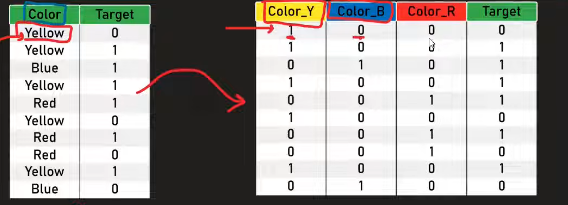

As first term is yellow, so 1 in color_Y column and 0 in rest
2nd is yellow, same
3rd is blue, so 1 in color_blue column and 0 in rest
similar for others